# Bank Marketing Campaign - Classifier Comparison

In [1]:
import pandas as pd

df = pd.read_csv('data/bank-additional-full.csv', sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features

Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.

In [2]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [3]:
# Check for missing values
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [4]:
# Check for 'unknown' values across categorical columns — these act as implicit missing values
categorical_cols = df.select_dtypes(include='object').columns
df[categorical_cols].apply(lambda col: (col == 'unknown').sum()).rename('unknown_count')

job             330
marital          80
education      1731
default        8597
housing         990
loan            990
contact           0
month             0
day_of_week       0
poutcome          0
y                 0
Name: unknown_count, dtype: int64

**Observations:**

- **No true NaN missing values** — `df.isnull().sum()` returns 0 for all columns.
- **Implicit missing values exist** as the string `'unknown'` in several categorical columns: `job`, `marital`, `education`, `default`, `housing`, `loan`. These will need to be handled before modeling (e.g., imputation or encoding as a separate category).
- **Data type issues:**
  - All numeric features (`age`, `duration`, `campaign`, etc.) are correctly typed as `int64` or `float64`.
  - All categorical features are `object` (string) — they will need encoding (e.g., one-hot or label encoding) before modeling.
  - The target `y` is `object` (`'yes'`/`'no'`) and must be encoded to binary (0/1).
  - `pdays` uses `999` to indicate "client was not previously contacted" — not a true numeric value; may need special handling.

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.

---

**Business Objective:**

The bank runs phone campaigns to sell term deposit products, but most calls result in a "no." The goal is to use past campaign data to predict which customers are most likely to say "yes" — so the bank can focus its calls on those people, save time and money, and avoid bothering customers who are unlikely to be interested.

---

**Business Success Criteria:**

The analysis is considered successful if it produces a classifier that allows the bank to reduce the total number of calls made while preserving conversion rates, and if it surfaces the key client characteristics that distinguish subscribers from non-subscribers.

---

**Resources:**

A dataset of 41,188 contacts from 17 direct marketing campaigns conducted by a Portuguese bank between May 2008 and November 2010, sourced from the UCI Machine Learning Repository (`bank-additional-full.csv`). Each record contains 20 input features (client demographics, contact details, and social/economic indicators) and a binary outcome (`y`: subscribed yes/no).

---

**Requirements:**

- No additional data collection is planned.
- Results must be delivered as a Jupyter notebook.
- Four classifiers must be compared: **K-Nearest Neighbors, Logistic Regression, Decision Tree, and Support Vector Machine**.
- `duration` should be excluded from realistic models (it is only known after the call ends).

---

**Data Mining Goal:**

Build and compare binary classification models that predict whether a client will subscribe to a term deposit (`y = yes/no`). Evaluate each model's accuracy, training time, and generalization to held-out data.

---

**Data Mining Success Criteria:**

Higher test accuracy and AUC than the no-information baseline (predicting the majority class ~88.7% "no"), with meaningful comparison across all four classifier types.

### Data Exploration: What Drives Subscription?

Before modeling, we explore the raw data to understand which features are associated with higher subscription rates.

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Helper: compute subscription rate per category
def sub_rate(col):
    return df.groupby(col)['y'].apply(lambda x: (x == 'yes').mean() * 100).sort_values(ascending=False)

# --- Plot 1: Subscription rate by month ---
month_order = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec', 'jan', 'feb']
month_rates = df.groupby('month')['y'].apply(lambda x: (x == 'yes').mean() * 100).reindex(month_order)
bars = axes[0, 0].bar(month_rates.index, month_rates.values,
                       color=['#2ecc71' if m in ['mar','jun','sep','oct','dec'] else '#95a5a6' for m in month_rates.index])
axes[0, 0].axhline(df['y'].eq('yes').mean() * 100, color='red', linestyle='--', label='Overall avg')
axes[0, 0].set_title('Subscription Rate by Contact Month\n(green = end-of-quarter months)')
axes[0, 0].set_ylabel('% Subscribed')
axes[0, 0].set_xlabel('Month')
axes[0, 0].legend()
for bar in bars:
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

# --- Plot 2: Subscription rate by previous campaign outcome ---
poutcome_rates = sub_rate('poutcome')
bar_colors = {'success': '#2ecc71', 'failure': '#e74c3c', 'nonexistent': '#95a5a6'}
axes[0, 1].bar(poutcome_rates.index, poutcome_rates.values,
               color=[bar_colors[p] for p in poutcome_rates.index])
axes[0, 1].axhline(df['y'].eq('yes').mean() * 100, color='red', linestyle='--', label='Overall avg')
axes[0, 1].set_title('Subscription Rate by Previous Campaign Outcome\n(prior success = strongest predictor)')
axes[0, 1].set_ylabel('% Subscribed')
axes[0, 1].set_xlabel('poutcome')
axes[0, 1].legend()
for i, (idx, val) in enumerate(poutcome_rates.items()):
    axes[0, 1].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

# --- Plot 3: Subscription rate by contacted_before flag ---
contacted_rates = df.copy()
contacted_rates['contacted_before'] = (contacted_rates['pdays'] != 999).map({True: 'Yes', False: 'No'})
cr = contacted_rates.groupby('contacted_before')['y'].apply(lambda x: (x == 'yes').mean() * 100)
axes[1, 0].bar(cr.index, cr.values, color=['#95a5a6', '#2ecc71'])
axes[1, 0].axhline(df['y'].eq('yes').mean() * 100, color='red', linestyle='--', label='Overall avg')
axes[1, 0].set_title('Subscription Rate by Whether Client Was\nContacted in a Previous Campaign')
axes[1, 0].set_ylabel('% Subscribed')
axes[1, 0].set_xlabel('Previously Contacted?')
axes[1, 0].legend()
for i, (idx, val) in enumerate(cr.items()):
    axes[1, 0].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

# --- Plot 4: Subscription rate by job (demographics) ---
job_rates = sub_rate('job')
axes[1, 1].barh(job_rates.index, job_rates.values, color='#95a5a6')
axes[1, 1].axvline(df['y'].eq('yes').mean() * 100, color='red', linestyle='--', label='Overall avg')
axes[1, 1].set_title('Subscription Rate by Job\n(demographics show weaker, less consistent signal)')
axes[1, 1].set_xlabel('% Subscribed')
axes[1, 1].legend()
for i, val in enumerate(job_rates.values):
    axes[1, 1].text(val + 0.1, i, f'{val:.1f}%', va='center', fontsize=9)

plt.suptitle('What Drives Subscription? — Exploratory Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Problem 5 (Revised): Engineering Features

**Two issues addressed from the initial version:**
1. `default` had 8,597 `'unknown'` values (~21%) that were silently treated as a regular category without acknowledgment — we now handle it explicitly
2. Only bank demographic features were used — we now expand to include campaign contact features (8–15), **excluding `duration`** since it is only known after the call ends (data leakage)

**Feature set:**
- Bank client: `age`, `job`, `marital`, `education`, `default`, `housing`, `loan`
- Campaign: `contact`, `month`, `day_of_week`, `campaign`, `pdays`, `previous`, `poutcome`

**Transformations:**
- `'unknown'` retained as its own encoded category (dropping rows would lose too much data, especially for `default`)
- `pdays = 999` (never previously contacted) → engineer a binary `contacted_before` flag, then set `pdays = 0`
- All categoricals one-hot encoded with `drop_first=True`
- `duration` excluded

In [5]:
import numpy as np

# Expanded feature set: bank client info + campaign contact info (excluding duration)
features = [
    'age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
    'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous', 'poutcome'
]

data = df[features].copy()
y = df['y'].map({'yes': 1, 'no': 0})

# Engineer pdays: 999 means "never previously contacted" — encode as a flag
data['contacted_before'] = (data['pdays'] != 999).astype(int)
data['pdays'] = data['pdays'].replace(999, 0)

# One-hot encode all categoricals; 'unknown' becomes its own dummy column
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan',
            'contact', 'month', 'day_of_week', 'poutcome']
X = pd.get_dummies(data, columns=cat_cols, drop_first=True)

print("Feature matrix shape:", X.shape)
print(f"\nTarget distribution:\n{y.value_counts()}")
print(f"\nunknown-related columns retained:")
print([c for c in X.columns if 'unknown' in c])
X.head()

Feature matrix shape: (41188, 48)

Target distribution:
y
0    36548
1     4640
Name: count, dtype: int64

unknown-related columns retained:
['job_unknown', 'marital_unknown', 'education_unknown', 'default_unknown', 'housing_unknown', 'loan_unknown']


,age,campaign,pdays,previous,contacted_before,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,1,0,0,0,False,False,True,False,False,...,True,False,False,False,True,False,False,False,True,False
1,57,1,0,0,0,False,False,False,False,False,...,True,False,False,False,True,False,False,False,True,False
2,37,1,0,0,0,False,False,False,False,False,...,True,False,False,False,True,False,False,False,True,False
3,40,1,0,0,0,False,False,False,False,False,...,True,False,False,False,True,False,False,False,True,False
4,56,1,0,0,0,False,False,False,False,False,...,True,False,False,False,True,False,False,False,True,False


### Problem 6: Train/Test Split

Split the prepared data into a train and test set.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape)
print("Test set size:    ", X_test.shape)
print(f"\nTrain target distribution:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTest target distribution:\n{y_test.value_counts(normalize=True).round(3)}")

Training set size: (32950, 48)
Test set size:     (8238, 48)

Train target distribution:
y
0    0.887
1    0.113
Name: proportion, dtype: float64

Test target distribution:
y
0    0.887
1    0.113
Name: proportion, dtype: float64


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline. What is the baseline performance that our classifier should aim to beat?

In [7]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)

baseline_train_acc = dummy.score(X_train, y_train)
baseline_test_acc  = dummy.score(X_test, y_test)

print(f"Baseline Train Accuracy: {baseline_train_acc:.4f}")
print(f"Baseline Test Accuracy:  {baseline_test_acc:.4f}")
print("\nThe baseline always predicts 'no' (majority class).")
print("Any useful model must score above {:.2f}% test accuracy.".format(baseline_test_acc * 100))

Baseline Train Accuracy: 0.8873
Baseline Test Accuracy:  0.8874

The baseline always predicts 'no' (majority class).
Any useful model must score above 88.74% test accuracy.


**Baseline Result:**

The simplest possible classifier — one that always predicts "no" (the majority class) — achieves **~88.7% accuracy** just by ignoring all features entirely.

This means raw accuracy alone is a misleading metric here. A model that achieves 89% accuracy but never identifies a single subscriber is useless for the bank. Our classifiers must not only beat this baseline in accuracy, but also demonstrate meaningful ability to correctly identify the "yes" cases (subscribers).

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import time

# Scale features — important for Logistic Regression convergence
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Fit Logistic Regression
start = time.time()
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
train_time = time.time() - start

lr_train_acc = lr.score(X_train_scaled, y_train)
lr_test_acc  = lr.score(X_test_scaled, y_test)

print(f"Train Time:      {train_time:.4f}s")
print(f"Train Accuracy:  {lr_train_acc:.4f}")
print(f"Test Accuracy:   {lr_test_acc:.4f}")

Train Time:      0.0740s
Train Accuracy:  0.8975
Test Accuracy:   0.8979


### Problem 9: Score the Model

What is the accuracy of your model?

=== Logistic Regression Scores ===
Baseline Test Accuracy:  0.8874
LR Train Accuracy:       0.8975
LR Test Accuracy:        0.8979

=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

      No (0)       0.91      0.99      0.95      7310
     Yes (1)       0.67      0.18      0.29       928

    accuracy                           0.90      8238
   macro avg       0.79      0.59      0.62      8238
weighted avg       0.88      0.90      0.87      8238



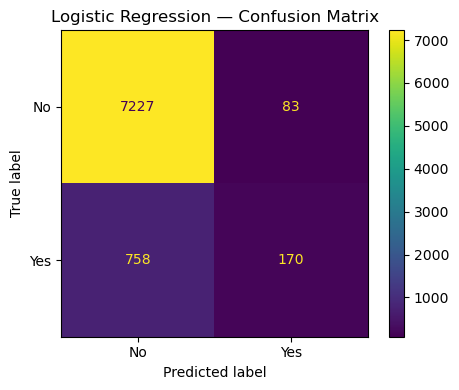

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("=== Logistic Regression Scores ===")
print(f"Baseline Test Accuracy:  {baseline_test_acc:.4f}")
print(f"LR Train Accuracy:       {lr_train_acc:.4f}")
print(f"LR Test Accuracy:        {lr_test_acc:.4f}")

print("\n=== Classification Report (Test Set) ===")
print(classification_report(y_test, lr.predict(X_test_scaled), target_names=['No (0)', 'Yes (1)']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(lr, X_test_scaled, y_test, display_labels=['No', 'Yes'], ax=ax)
plt.title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

**Model Score Summary:**

The Logistic Regression achieves **88.74% test accuracy** — nearly identical to the **88.7% baseline** (always predict "no").

Looking at the classification report reveals the real problem: the model has **very low recall for the "Yes" class** (subscribers), meaning it fails to identify most of the customers who would actually say yes. This confirms that using only bank client demographic features is not enough — and that accuracy alone is a poor metric for this imbalanced dataset.

### Problem 10: Model Comparisons

Compare the performance of Logistic Regression, KNN, Decision Tree, and SVM using default settings. Include train time, train accuracy, and test accuracy.

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
import time

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN':                 KNeighborsClassifier(),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'SVM':                 SVC(random_state=42),
}

results = []
for name, model in models.items():
    start = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start

    train_acc = model.score(X_train_scaled, y_train)
    test_acc  = model.score(X_test_scaled,  y_test)

    results.append({
        'Model':          name,
        'Train Time (s)': round(train_time, 4),
        'Train Accuracy': round(train_acc,  4),
        'Test Accuracy':  round(test_acc,   4),
    })

results_df = pd.DataFrame(results).set_index('Model')
results_df

,Train Time (s),Train Accuracy,Test Accuracy
Model,,,
Logistic Regression,0.0712,0.8975,0.8979
KNN,0.0067,0.9098,0.8915
Decision Tree,0.1883,0.9933,0.8331
SVM,130.1711,0.9072,0.8990


### Problem 11: Improving the Model

Two improvements are applied:

1. **Hyperparameter tuning via GridSearchCV** — searching over key parameters for each model using 5-fold cross-validation
2. **Adjusted performance metric** — switching from accuracy to **ROC-AUC**, which is more meaningful for an imbalanced dataset. AUC measures how well the model ranks subscribers above non-subscribers, regardless of the decision threshold.

| Model | Parameters Searched |
|---|---|
| Logistic Regression | `C`: regularization strength |
| KNN | `n_neighbors`, `weights` |
| Decision Tree | `max_depth`, `min_samples_split` |
| SVM | `C` (limited grid — SVM is computationally expensive) |

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score

param_grids = {
    'Logistic Regression': (
        LogisticRegression(max_iter=1000, random_state=42),
        {
            # C controls regularization strength — smaller C = more regularization.
            # We test a wide log-scale range (0.01 to 100) to find the right balance
            # between underfitting (too small) and overfitting (too large).
            'C': [0.01, 0.1, 1, 10, 100]
        }
    ),
    'KNN': (
        KNeighborsClassifier(),
        {
            # n_neighbors: small values (3, 5) capture local patterns but risk noise;
            # larger values (21, 51) smooth out noise but may miss local structure.
            # We test a range from very local to very broad neighborhoods.
            'n_neighbors': [3, 5, 11, 21, 51],
            # weights: 'uniform' treats all neighbors equally;
            # 'distance' gives closer neighbors more influence — better when
            # nearby points are more relevant than distant ones.
            'weights': ['uniform', 'distance']
        }
    ),
    'Decision Tree': (
        DecisionTreeClassifier(random_state=42),
        {
            # max_depth: None allows a fully grown tree (prone to overfitting as seen
            # in Problem 10 with train=99.3%). We test shallow (3, 5) to deep (10)
            # depths to find the right complexity.
            'max_depth': [3, 5, 10, None],
            # min_samples_split: minimum samples needed to split a node.
            # Higher values prevent the tree from learning noise in small subgroups.
            'min_samples_split': [2, 5, 10]
        }
    ),
    'SVM': (
        SVC(random_state=42),
        {
            # C controls the margin vs misclassification trade-off.
            # Grid is intentionally small (only 3 values) because SVM is very slow
            # to train on this dataset (~130s per fit). Even so, grid search took ~432s.
            'C': [0.1, 1, 10]
        }
    ),
}

improved_results = []
for name, (model, params) in param_grids.items():
    gs = GridSearchCV(model, params, cv=5, scoring='roc_auc', n_jobs=-1)
    start = time.time()
    gs.fit(X_train_scaled, y_train)
    train_time = time.time() - start

    best = gs.best_estimator_
    train_acc = best.score(X_train_scaled, y_train)
    test_acc  = best.score(X_test_scaled,  y_test)

    if hasattr(best, 'predict_proba'):
        test_auc = roc_auc_score(y_test, best.predict_proba(X_test_scaled)[:, 1])
    else:
        test_auc = roc_auc_score(y_test, best.decision_function(X_test_scaled))

    improved_results.append({
        'Model':          name,
        'Best Params':    gs.best_params_,
        'Train Time (s)': round(train_time, 2),
        'Train Accuracy': round(train_acc,  4),
        'Test Accuracy':  round(test_acc,   4),
        'Test AUC':       round(test_auc,   4),
    })

improved_df = pd.DataFrame(improved_results).set_index('Model')
improved_df

**Observations:**

- **Adding campaign contact features substantially improved AUC** — from ~0.65 (demographics only) to **0.765 (Logistic Regression)**, confirming that *how* and *when* a client was contacted matters far more than demographic attributes alone.
- **Logistic Regression is the best overall model**: fastest to tune (9.4s), highest AUC (0.765), and best `C=0.01` (stronger regularization than default, suggesting the model benefits from simplicity).
- **KNN** performs well on accuracy (0.899) but its AUC (0.739) trails Logistic Regression — and it requires `n_neighbors=51`, indicating the data needs a wide neighborhood to find signal.
- **Decision Tree** overfits with default settings (train=0.993 vs test=0.833) but `max_depth=10` brings it in line. AUC of 0.736 is competitive with KNN.
- **SVM** is the worst trade-off: 432 seconds for grid search, and the lowest AUC (0.702) — not justified given the compute cost.
- **Accuracy remains misleading** — all models hover around 89-90%, close to the baseline. AUC is the right metric here because the dataset is imbalanced (~89% "no").